In [ ]:
!pip install openai-whisper --quiet #Transcription

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.5/800.5 kB 10.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 855.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.1 MB/s 

In [ ]:
!pip install git+https://github.com/openai/whisper.git --quiet

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!pip install torchaudio transformers librosa soundfile --quiet   #transformers - sentiment #tourch,librosa,soundfile - processing audio

In [72]:
!pip install sounddevice numpy openai-whisper soundfile

In [79]:
from IPython.display import display, Javascript, Audio, clear_output
from base64 import b64decode
import whisper
import ipywidgets as widgets
from google.colab import output

# Load Whisper model
model = whisper.load_model("base")

# Global result container
result = {}

# Save + assign transcription to `result`
def save_audio(data_url):
    global result
    header, encoded = data_url.split(",", 1)
    audio_bytes = b64decode(encoded)
    with open("user_audio.wav", "wb") as f:
        f.write(audio_bytes)
    print("✅ Audio saved as user_audio.wav")
    display(Audio("user_audio.wav"))

    result = model.transcribe("user_audio.wav")
    print("\n📜 Transcription:\n")
    print(result["text"])

# Register JS callback
output.register_callback('notebook.save_audio', save_audio)

# Create buttons
start_btn = widgets.Button(description="🎙 Start Recording", button_style='success')
stop_btn = widgets.Button(description="⏹ Stop & Transcribe", button_style='danger')
buttons = widgets.HBox([start_btn, stop_btn])
display(buttons)

# JS to start recording
start_js = """
navigator.mediaDevices.getUserMedia({ audio: true }).then(stream => {
  window.recorderStream = stream;
  window.recorder = new MediaRecorder(stream);
  window.audioChunks = [];
  recorder.ondataavailable = e => window.audioChunks.push(e.data);
  recorder.start();
  console.log("🎤 Recording started...");
});
"""

# JS to stop recording and trigger Python transcription
stop_js = """
recorder.stop();
recorder.onstop = async () => {
  const blob = new Blob(audioChunks, { type: 'audio/wav' });
  const reader = new FileReader();
  reader.onloadend = () => {
    const base64 = reader.result;
    google.colab.kernel.invokeFunction('notebook.save_audio', [base64], {});
  };
  reader.readAsDataURL(blob);
  recorderStream.getTracks().forEach(track => track.stop());
};
"""

# Button handlers
def on_start_clicked(b):
    clear_output(wait=True)
    display(buttons)
    display(Javascript(start_js))

def on_stop_clicked(b):
    display(Javascript(stop_js))

start_btn.on_click(on_start_clicked)
stop_btn.on_click(on_stop_clicked)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Audio saved as user_audio.wav


/usr/local/lib/python3.11/dist-packages/whisper/transcribe.py:126: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



📜 Transcription:




In [ ]:
import whisper

# Load the model (use "base" for faster performance, "small"/"medium"/"large" for more accuracy)
model = whisper.load_model("base")

# Assuming the uploaded filename (you can replace it with your exact file name if needed)
audio_file = list(uploaded.keys())[0]

# Transcribe
result = model.transcribe(audio_file)

# Print the full transcript
print("📄 Transcript:\n")
print(result["text"])


/usr/local/lib/python3.11/dist-packages/whisper/transcribe.py:126: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


📄 Transcript:

 The stale smell of old beer lingers. It takes heat to bring out the odor. A cold dip restores health and zest. A salt pickle tastes fine with ham. Tacos al pastor are my favorite. A zestful food is the hot cross bun.


In [ ]:
from transformers import pipeline
from collections import Counter, defaultdict
import re
import random


In [ ]:

# Emotion keyword bank
emotion_keywords = {
    "joy": ["happy", "joy", "excited", "smile", "fun", "delighted", "cheerful", "grateful", "thankful", "glad", "loved", "enthusiastic"],
    "sadness": ["sad", "down", "lonely", "unhappy", "depressed", "miss", "cry", "grief", "gloomy", "upset", "regret"],
    "anger": ["angry", "mad", "furious", "irritated", "annoyed", "rage", "hate", "offended", "resentful", "hostile"],
    "fear": ["scared", "afraid", "nervous", "fear", "worried", "anxious", "terrified", "panic", "insecure", "hesitant"],
    "disgust": ["disgust", "gross", "awful", "nasty", "terrible", "repulsed", "hate", "vomit", "revolting"],
    "surprise": ["surprised", "shocked", "amazed", "astonished", "unexpected", "startled", "stunned", "wow"],
    "neutral": ["ok", "fine", "normal", "regular", "average", "acceptable", "typical"]
}

# Parse transcript
transcript = result["text"]
sentences = re.split(r'(?<=[.!?])\s+', transcript.strip())

# Hybrid model + keyword emotion scoring
sentence_results = []

for sentence in sentences:
    if sentence.strip():
        model_output = emotion_pipeline(sentence)[0]
        model_label = model_output['label']
        model_score = round(model_output['score'], 2)

        # Check for keywords
        matched_tags = []
        for emotion_name, keywords in emotion_keywords.items():
            for word in keywords:
                if word in sentence.lower():
                    matched_tags.append((emotion_name, word))

        # Fallback to keyword tag if model score low
        if model_score < 0.6 and matched_tags:
            boosted_label = matched_tags[0][0]
            boosted_score = 0.65
            source = f"keyword fallback (e.g., '{matched_tags[0][1]}')"
        else:
            boosted_label = model_label
            boosted_score = model_score
            source = "model"

        sentence_results.append({
            'sentence': sentence.strip(),
            'emotion': boosted_label,
            'score': boosted_score,
            'source': source,
            'above_threshold': boosted_score >= 0.6
        })


In [ ]:
from collections import Counter

def generate_personacoach_report(sentence_results, transcript):
    report = "📝 PersonaCoach Session Report\n"
    report += "=======================================\n\n"

    # Emotion & Confidence
    scores = [s['score'] for s in sentence_results]
    avg_conf = round(sum(scores) / len(scores), 2)
    conf_score = int(avg_conf * 100)
    emotion_labels = [s['emotion'] for s in sentence_results if s['score'] >= 0.6]
    dominant_emotion, count = Counter(emotion_labels).most_common(1)[0] if emotion_labels else ("neutral", 0)

    # Filler Words
    filler_words = ["um", "uh", "like", "you know", "so", "actually", "basically", "literally"]
    words = transcript.lower().split()
    total_words = len(words)
    filler_count = sum(words.count(fw) for fw in filler_words)
    filler_ratio = filler_count / total_words

    # Harsh Words
    tone_softener = {
        "hate": "don’t enjoy", "awful": "not ideal", "terrible": "could be improved",
        "never": "hasn't worked yet", "disgusting": "off-putting", "useless": "not very effective",
        "worst": "least effective", "annoying": "a bit frustrating"
    }
    found_harsh = [f"'{h}' → '{s}'" for h, s in tone_softener.items() if h in transcript.lower()]

    # ===== Report Blocks =====
    report += f"🎯 Confidence Score: {conf_score}/100\n\n"

    report += "🗣️ Emotional Delivery:\n"
    if dominant_emotion == "neutral":
        report += "- Your tone was mostly neutral, with consistent clarity.\n"
        report += "- To make your speech more engaging, try varying your tone—use inflection for emphasis and drop it slightly to signal transitions.\n\n"
    else:
        report += f"- Detected a strong tone of '{dominant_emotion}' across your confident moments.\n"
        report += "- Use it intentionally to reinforce or soften your message depending on context.\n\n"

    report += "💬 Filler Words:\n"
    report += f"- {filler_count} filler words detected out of {total_words} total words.\n"
    if filler_ratio > 0.06:
        report += "- Too many filler words can distract. Pause briefly instead to sound more confident.\n\n"
    elif filler_ratio > 0.03:
        report += "- Some fillers used. Try to minimize them in key moments.\n\n"
    else:
        report += "- Excellent fluency. You maintained strong verbal control.\n\n"

    report += "🔊 Word Choice Feedback:\n"
    if found_harsh:
        report += "- Consider softening strong expressions to keep your tone constructive:\n"
        for pair in found_harsh:
            report += f"  • {pair}\n"
    else:
        report += "- No harsh expressions were detected—your phrasing felt polite and measured.\n"
    report += "- In persuasive settings, saying 'could be better' often lands softer than 'this is terrible'.\n\n"

    report += "🎧 Audio Delivery Insights:\n"
    if avg_conf >= 0.75:
        report += "- Your voice projected clarity and confidence across most of the session.\n"
    if filler_ratio < 0.03:
        report += "- Minimal use of filler words made your speech sound polished and fluent.\n"
    if avg_conf < 0.6:
        report += "- Some segments may have lacked emotional emphasis — try using more vocal variety.\n"
    if filler_ratio > 0.06:
        report += "- Filler-heavy delivery might affect pacing and confidence — consider pausing intentionally.\n"
    report += "\n"

    report += "💡 PersonaCoach Tips:\n"
    if avg_conf < 0.65:
        report += "- Practice reading aloud with vocal exaggeration to unlock more expressive delivery.\n"
    if filler_ratio > 0.04:
        report += "- Use strategic pauses instead of 'um' to hold attention and sound confident.\n"
    if dominant_emotion == "neutral":
        report += "- Try rephrasing with energetic starters like 'What’s exciting is…' or 'What matters most…'.\n"
    report += "- Record yourself again and listen critically. Track changes in tone, pace, and emphasis.\n\n"

    report += "✅ Strength Highlights:\n"
    if avg_conf >= 0.75 and filler_ratio < 0.03:
        report += "- Clear tone, strong fluency, and well-paced delivery.\n"
    else:
        report += "- Good structure and flow in many areas. Keep improving expression and confidence.\n"

    report += "\n🧭 Next Steps:\n"
    report += "- Focus on vocal variation and tone control in high-stakes moments.\n"
    report += "- Track your confidence score over sessions to see steady progress.\n"

    return report


In [ ]:
final_report = generate_personacoach_report(sentence_results, transcript)
print(final_report)


📝 PersonaCoach Session Report

🎯 Confidence Score: 75/100

🗣️ Emotional Delivery:
- Your tone was mostly neutral, with consistent clarity.
- To make your speech more engaging, try varying your tone—use inflection for emphasis and drop it slightly to signal transitions.

💬 Filler Words:
- 0 filler words detected out of 43 total words.
- Excellent fluency. You maintained strong verbal control.

🔊 Word Choice Feedback:
- No harsh expressions were detected—your phrasing felt polite and measured.
- In persuasive settings, saying 'could be better' often lands softer than 'this is terrible'.

🎧 Audio Delivery Insights:
- Your voice projected clarity and confidence across most of the session.
- Minimal use of filler words made your speech sound polished and fluent.

💡 PersonaCoach Tips:
- Try rephrasing with energetic starters like 'What’s exciting is…' or 'What matters most…'.
- Record yourself again and listen critically. Track changes in tone, pace, and emphasis.

✅ Strength Highlights:
- C

<ipython-input-61-37d6876c1278>:24: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


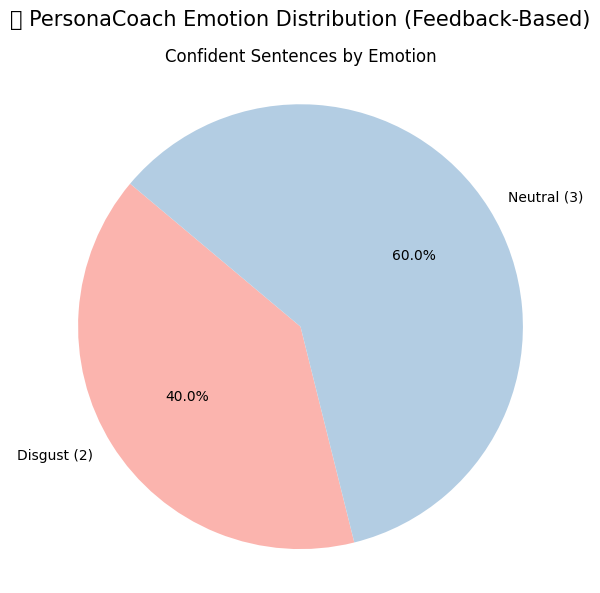

In [ ]:
import matplotlib.pyplot as plt


# Use only confident emotion entries from sentence_results
emotion_labels_from_report = [s['emotion'].capitalize() for s in sentence_results if s['score'] >= 0.6]
emotion_counts_from_report = Counter(emotion_labels_from_report)

# Plot clean pie chart
fig, ax = plt.subplots(figsize=(6, 6))
fig.suptitle("🎯 PersonaCoach Emotion Distribution (Feedback-Based)", fontsize=15)

colors = plt.cm.Pastel1(range(len(emotion_counts_from_report)))
ax.pie(
    emotion_counts_from_report.values(),
    labels=[f"{k} ({v})" for k, v in emotion_counts_from_report.items()],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'fontsize': 10}
)

ax.axis('equal')
ax.set_title("Confident Sentences by Emotion", fontsize=12)
plt.tight_layout()
plt.show()
